In [8]:
!pip install torch

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv('telecom_churn.csv')

In [4]:
if 'phone number' in df.columns: df = df.drop('phone number', axis=1)


df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})
df['churn'] = df['churn'].astype(int)


df = pd.get_dummies(df, columns=['state'], prefix='state')


df['total_minutes'] = df['total day minutes'] + df['total eve minutes'] + df['total night minutes'] + df['total intl minutes']
df['total_calls']   = df['total day calls'] + df['total eve calls'] + df['total night calls'] + df['total intl calls']
df['total_charge']  = df['total day charge'] + df['total eve charge'] + df['total night charge'] + df['total intl charge']
df['cost_per_minute'] = df['total_charge'] / df['total_minutes'].replace(0, 1)

In [5]:
# --- 3. SPLIT DATA ---
X = df.drop('churn', axis=1).values
y = df['churn'].values

# Stratify(to ensure churners are in both sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
train_df = pd.DataFrame(X_train)
train_df['churn'] = y_train

# Separate
majority = train_df[train_df['churn'] == 0]
minority = train_df[train_df['churn'] == 1]

# Upsample Minority to match Majority
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
upsampled_df = pd.concat([majority, minority_upsampled])

# Split back
X_train_final = upsampled_df.drop('churn', axis=1).values
y_train_final = upsampled_df['churn'].values

In [7]:
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_test = scaler.transform(X_test)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import classification_report

In [10]:
# PREPARE DATA (Convert from Pandas/NumPy to PyTorch Tensors)
# PyTorch needs float32 tensors for weights
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_final, dtype=torch.float32).unsqueeze(1) # Shape becomes (N, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoader (Handles batching automatically, like Keras batch_size=32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [36]:
# DEFINE THE MODEL (The Class)
class ChurnModel(nn.Module):
    def __init__(self, input_dim):
        super(ChurnModel, self).__init__()

        # Layer 1: Dense 32
        self.fc1 = nn.Linear(input_dim, 32)
        self.dropout1 = nn.Dropout(0.4)

        # Layer 2: Dense 16
        self.fc2 = nn.Linear(32, 16)
        self.dropout2 = nn.Dropout(0.4)

        # Layer 3: Output 1
        self.fc3 = nn.Linear(16, 1)

        # Activations
        self.relu = nn.ReLU()
        # DELETED: self.sigmoid = nn.Sigmoid()  <-- You don't need this anymore!

    def forward(self, x):
        # Flow: Input -> FC1 -> ReLU -> Dropout -> FC2 -> ReLU -> Dropout -> FC3
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)

        x = self.relu(self.fc2(x))
        x = self.dropout2(x)

        # CHANGED HERE: Return raw output (logits)
        x = self.fc3(x)
        return x

In [37]:
# Initialize Model
input_features = X_train_final.shape[1] # Should be 20 based on your CSV
model = ChurnModel(input_features)

In [38]:
criterion = nn.BCEWithLogitsLoss()

# Adam Optimizer with L2 Regularization (weight_decay simulates L2 reg)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

In [39]:
import matplotlib.pyplot as plt

# --- 1. SETUP HISTORY LISTS (The Manual "History" Object) ---
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

# --- 2. TRAINING LOOP WITH TRACKING ---
epochs = 50

for epoch in range(epochs):
    # A. TRAIN PHASE
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Track Train Loss
        running_loss += loss.item()

        # Track Train Accuracy (Threshold 0.5 for binary)
        predicted = (outputs > 0.5).float()
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    # Calculate Epoch Averages
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train

    # Store in history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)

    # B. VALIDATION PHASE
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        inputs, labels = X_test_tensor, y_test_tensor # Use full test set
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        val_loss = loss.item()
        predicted = (outputs > 0.5).float()
        correct_val += (predicted == labels).sum().item()
        total_val += labels.size(0)

    epoch_val_acc = correct_val / total_val

    # Store in history
    history['val_loss'].append(val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}: Train Loss {epoch_train_loss:.4f} | Val Loss {val_loss:.4f}")

Epoch 1: Train Loss 0.6616 | Val Loss 0.6059
Epoch 2: Train Loss 0.5559 | Val Loss 0.5326
Epoch 3: Train Loss 0.4702 | Val Loss 0.4589
Epoch 4: Train Loss 0.4187 | Val Loss 0.4337
Epoch 5: Train Loss 0.3920 | Val Loss 0.4136
Epoch 6: Train Loss 0.3721 | Val Loss 0.3973
Epoch 7: Train Loss 0.3639 | Val Loss 0.4115
Epoch 8: Train Loss 0.3400 | Val Loss 0.3996
Epoch 9: Train Loss 0.3357 | Val Loss 0.3883
Epoch 10: Train Loss 0.3144 | Val Loss 0.3774
Epoch 11: Train Loss 0.3094 | Val Loss 0.3729
Epoch 12: Train Loss 0.3063 | Val Loss 0.3758
Epoch 13: Train Loss 0.2903 | Val Loss 0.3733
Epoch 14: Train Loss 0.2885 | Val Loss 0.3774
Epoch 15: Train Loss 0.2863 | Val Loss 0.3854
Epoch 16: Train Loss 0.2725 | Val Loss 0.3634
Epoch 17: Train Loss 0.2615 | Val Loss 0.3809
Epoch 18: Train Loss 0.2620 | Val Loss 0.3668
Epoch 19: Train Loss 0.2578 | Val Loss 0.3646
Epoch 20: Train Loss 0.2584 | Val Loss 0.3660
Epoch 21: Train Loss 0.2560 | Val Loss 0.3661
Epoch 22: Train Loss 0.2342 | Val Loss 0.37

In [40]:
#  FINAL EVALUATION
# Load best model
# model.load_state_dict(torch.load('best_model.pth')) # This line caused the error due to architecture mismatch
model.eval()

with torch.no_grad():
    y_pred_prob = model(X_test_tensor)
    y_pred = (y_pred_prob > 0.6).int().numpy()

print("\n--- Final Report (PyTorch) ---")
print(classification_report(y_test, y_pred))


--- Final Report (PyTorch) ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       570
           1       0.60      0.60      0.60        97

    accuracy                           0.88       667
   macro avg       0.76      0.76      0.76       667
weighted avg       0.88      0.88      0.88       667



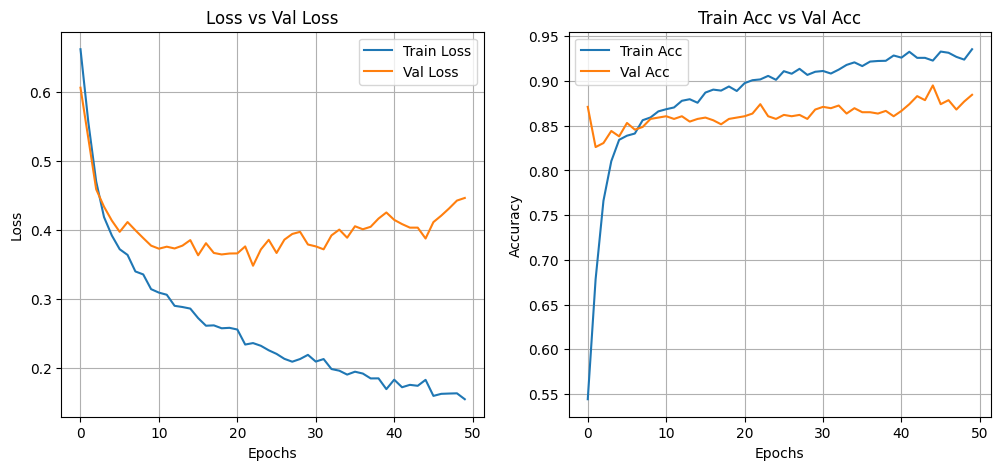

In [41]:
plt.figure(figsize=(12, 5))

# Plot 1: Loss vs Val_Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss vs Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Train Acc vs Val Acc
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Train Acc vs Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()